In [21]:
# Install the necessary packages
!pip install -U ragas -q
!pip install langchain==1.2.10 langchain-core==1.2.23 langchain-google-genai==4.2.1 -q
!pip install google-generativeai -q
!pip install datasets==4.0.0 -q
!pip install pypdf2 -q
!pip install python-dotenv -q
!pip install numpy -q
!pip install seaborn matplotlib -q

In [22]:
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import google.generativeai as genai
from dotenv import load_dotenv

BASE_PATH = Path(r"D:\MyProjects\AI Project\evaluate_rag_application_ragas")
PDF_PATH = BASE_PATH / "codeprolk.pdf"
CSV_PATH = BASE_PATH / "test_data.csv"
ENV_PATH = BASE_PATH / ".env"

load_dotenv(dotenv_path=ENV_PATH)
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY was not found in .env")

genai.configure(api_key=GEMINI_API_KEY)

In [23]:
# Initialize Gemini models

PREFERRED_GENERATION_MODELS = [
    "models/gemini-1.5-flash",
    "models/gemini-1.5-pro",
    "models/gemini-1.0-pro",
]
PREFERRED_EMBEDDING_MODELS = [
    "models/text-embedding-004",
    "models/text-embedding-005",
    "models/gemini-embedding-001",
    "models/embedding-001",
]

available_models = list(genai.list_models())

available_generation_models = [
    m.name
    for m in available_models
    if "generateContent" in getattr(m, "supported_generation_methods", [])
]
available_embedding_models = [
    m.name
    for m in available_models
    if "embedContent" in getattr(m, "supported_generation_methods", [])
]

for candidate in PREFERRED_GENERATION_MODELS:
    if candidate in available_generation_models:
        GENERATION_MODEL = candidate
        break
else:
    if not available_generation_models:
        raise RuntimeError("No generation models with generateContent support are available for this API key.")
    GENERATION_MODEL = available_generation_models[0]

for candidate in PREFERRED_EMBEDDING_MODELS:
    if candidate in available_embedding_models:
        EMBEDDING_MODEL = candidate
        break
else:
    if not available_embedding_models:
        raise RuntimeError("No embedding models with embedContent support are available for this API key.")
    EMBEDDING_MODEL = available_embedding_models[0]

print("Using generation model:", GENERATION_MODEL)
print("Using embedding model:", EMBEDDING_MODEL)

llm = genai.GenerativeModel(GENERATION_MODEL)

Using generation model: models/gemini-2.5-flash
Using embedding model: models/gemini-embedding-001


In [24]:
# Embedding helper
import numpy as np

def embed_text(text: str, task_type: str = "retrieval_document") -> np.ndarray:
    result = genai.embed_content(
        model=EMBEDDING_MODEL,
        content=text,
        task_type=task_type,
    )
    embedding = result["embedding"]
    if isinstance(embedding, dict) and "values" in embedding:
        embedding = embedding["values"]
    return np.array(embedding, dtype=np.float32)

In [25]:
# Load PDF document
from PyPDF2 import PdfReader

reader = PdfReader(str(PDF_PATH))
pages = [page.extract_text() or "" for page in reader.pages]
full_text = "\n\n".join(pages)

len(pages), len(full_text)

(4, 6847)

In [26]:
# Split text into chunks

def chunk_text(text: str, chunk_size: int = 300, chunk_overlap: int = 40):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        if end >= len(text):
            break
        start = end - chunk_overlap
    return chunks

splits = chunk_text(full_text, chunk_size=300, chunk_overlap=40)
len(splits)

27

In [27]:
# Build embeddings and retrieval

chunk_embeddings = np.vstack([embed_text(chunk, task_type="retrieval_document") for chunk in splits])

def retrieve_context(query: str, k: int = 4):
    query_embedding = embed_text(query, task_type="retrieval_query")
    query_norm = np.linalg.norm(query_embedding) + 1e-10
    chunk_norms = np.linalg.norm(chunk_embeddings, axis=1) + 1e-10
    scores = (chunk_embeddings @ query_embedding) / (chunk_norms * query_norm)
    top_idx = np.argsort(scores)[-k:][::-1]
    return [splits[i] for i in top_idx]

In [28]:
# Prompt template

PROMPT_TEMPLATE = """Answer the question using only the context below.\nIf the context does not contain the answer, say you do not know.\n\nQuestion:\n{question}\n\nContext:\n{context}\n"""

In [29]:
# RAG answer function without LangChain

def answer_query(query: str, k: int = 4):
    contexts = retrieve_context(query, k=k)
    context_text = "\n\n".join(contexts)
    prompt = PROMPT_TEMPLATE.format(question=query, context=context_text)
    response = llm.generate_content(prompt)
    answer = (response.text or "").strip()
    return answer, contexts

In [37]:
# Invoke RAG with an example question

response, context = answer_query("what is the codeprolk")

print(response)

CodePRO LK is a dynamic educational platform that offers a diverse range of technology-related courses in Sinhala, aimed at empowering Sri Lankans with valuable skills in programming, data science, and machine learning.


In [39]:
# Evaluate RAG application
import pandas as pd

test_data = pd.read_csv(CSV_PATH)
test_data

questions = test_data["question"].to_list()
ground_truth = test_data["answer"].to_list()

questions

['what is codeprolk',
 'what is the main vision of them',
 'what is the mission of codeprolk',
 'What are the courses they offer',
 'These courses are for which nationality',
 'what are the popular videos in codeprolk youtube channel']

In [40]:
data = {"question": [], "answer": [], "contexts": [], "ground_truth": ground_truth}

for query in questions:
    answer, contexts = answer_query(query)
    data["question"].append(query)
    data["answer"].append(answer)
    data["contexts"].append(contexts)

In [41]:
from datasets import Dataset

dataset = Dataset.from_dict(data)

dataset

dataset[5]

from ragas.metrics import context_precision, context_recall, answer_relevancy, faithfulness
from ragas import evaluate

In [42]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.llms import LangchainLLMWrapper
from ragas.metrics import context_precision, context_recall, answer_relevancy, faithfulness
from ragas import evaluate

evaluator_llm = LangchainLLMWrapper(
    ChatGoogleGenerativeAI(
        model=GENERATION_MODEL.replace("models/", ""),
        google_api_key=GEMINI_API_KEY,
    )
)
evaluator_embeddings = LangchainEmbeddingsWrapper(
    GoogleGenerativeAIEmbeddings(
        model=EMBEDDING_MODEL,
        google_api_key=GEMINI_API_KEY,
    )
)

result = evaluate(
    dataset=dataset,
    metrics=[
        context_precision,
        context_recall,
        answer_relevancy,
        faithfulness,
    ],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    show_progress=True,
)

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


In [43]:
result

results = result.to_pandas()
results

,user_input,retrieved_contexts,response,reference,context_precision,context_recall,answer_relevancy,faithfulness
0,what is codeprolk,[Introduction to CodePRO LK \nCodePRO LK is ...,CodePRO LK is a dynamic educational platform t...,CodePRO LK is a dynamic educational platform ...,0.833333,1.0,0.843511,1.0
1,what is the main vision of them,"[igitally -driven world, all through their nat...",To assist talented Sri Lankans in reaching the...,To assist talented Sri Lankans in reaching th...,0.750000,1.0,0.704135,1.0
2,what is the mission of codeprolk,[d improve learner progress effectively. \nCo...,CodePRO LK was launched to provide Sri Lankan ...,To produce high-quality tech courses and arti...,0.000000,0.0,0.797144,1.0
3,What are the courses they offer,"[ various proficiency levels, from beginners t...",The courses offered are:\n1. Python GUI – Tkin...,CodeProLK offers courses like Python GUI with...,0.833333,1.0,0.795022,1.0
4,These courses are for which nationality,"[igitally -driven world, all through their nat...",Sri Lankans,CodeProLK's courses are designed specifically...,1.000000,1.0,0.646020,1.0
5,what are the popular videos in codeprolk youtu...,[or personalized \nlearning support. \n \nCod...,The popular videos in the CodePRO LK YouTube c...,It features popular videos like Python Basics...,0.500000,0.0,0.833555,1.0


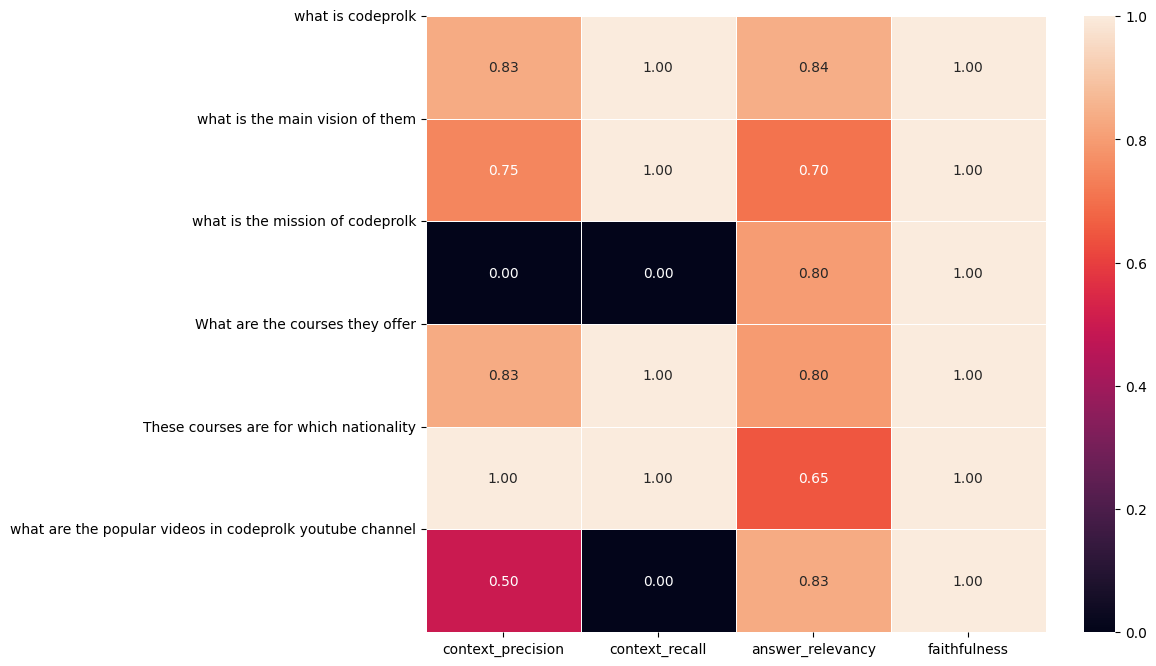

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = results[["context_precision", "context_recall", "answer_relevancy", "faithfulness"]]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", linewidths=.5)

if "question" in results.columns:
    y_labels = results["question"].tolist()
else:
    y_labels = questions[: len(results)]

plt.yticks(ticks=range(len(y_labels)), labels=y_labels, rotation=0)

plt.show()